# ARIA — Attrition Risk Insight Analyzer
## YouTube Sentiment Pipeline
### Model Upgrade: TextBlob → VADER → RoBERTa

**Business Question:**
Do basic sentiment models accurately capture how Amazon warehouse workers
feel in spoken video testimonials and what happens when we upgrade to
a transformer model?

**What this notebook does:**
1. Loads YouTube transcript data
2. Runs VADER as the baseline model
3. Runs RoBERTa as the upgraded model
4. Compares both outputs side by side
5. Shows where basic models fail on spoken content

**Dataset:** 10 YouTube testimonials | Amazon warehouse workers

In [2]:
# Install required libraries
!pip install transformers torch -q
!pip install vaderSentiment -q
!pip install textblob -q
!pip install pandas matplotlib seaborn -q

print("All libraries installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.6 MB/s eta 0:00:00
All libraries installed.


## Step 1 — Import Libraries and Upload Data

In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from transformers import pipeline
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported.")

Libraries imported.


In [4]:
# Upload your YouTube dataset
print("Upload youtube_final_v2.csv")
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\nLoaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst row preview:")
print(df.head(1).T)

Upload youtube_final_v2.csv


Saving youtube_final_v2.csv to youtube_final_v2.csv

Loaded: 10 rows, 26 columns

Columns: ['s_no', 'link', 'upload_date', 'station_type', 'views', 'likes', 'comments', 'like_rate', 'comment_rate', 'sentiment', 'would_they_return', 'pain_points', 'reason_for_leaving', 'key_themes', 'sentiment_group', 'return_flag', 'tb_score', 'tb_subjectivity', 'tb_label', 'tb_aligned', 'vdr_score', 'vdr_label', 'vdr_aligned', 'transcript_cleaned', 'pain_points_cleaned', 'key_themes_cleaned']

First row preview:
                                                                     0
s_no                                                                 1
link                                   My Experience Working At Amazon
upload_date                                                   Feb 2025
station_type                                          Delivery Station
views                                                               86
likes                                                                2
c

## Step 2 — Identify Text Column and Confirm Baseline Scores

In [5]:
# Confirm the text column we will run RoBERTa on
text_col = 'transcript_cleaned'

print("TEXT COLUMN:", text_col)
print(f"Null values: {df[text_col].isnull().sum()}")
print()

# Show existing baseline scores
print("EXISTING BASELINE SCORES:")
print(df[['s_no', 'tb_label', 'tb_score', 'vdr_label', 'vdr_score', 'sentiment']].to_string())
print()

# Quick summary
print("TEXTBLOB LABEL COUNTS:")
print(df['tb_label'].value_counts())
print()
print("VADER LABEL COUNTS:")
print(df['vdr_label'].value_counts())
print()
print("HUMAN SENTIMENT COUNTS:")
print(df['sentiment_group'].value_counts())

TEXT COLUMN: transcript_cleaned
Null values: 0

EXISTING BASELINE SCORES:
   s_no  tb_label  tb_score vdr_label  vdr_score                 sentiment
0     1   neutral     0.065  positive      0.996  Mixed (neutral-negative)
1     2  positive     0.126  positive      0.976  Mixed (positive-neutral)
2     3   neutral     0.066  positive      0.809                  Negative
3     4  positive     0.171  positive      0.983                  Positive
4     5   neutral     0.044  negative     -0.865                  Negative
5     6   neutral     0.016  positive      0.567                  Negative
6     7  positive     0.111  positive      0.969                  Positive
7     8   neutral     0.051  negative     -0.901                  Negative
8     9   neutral     0.046  negative     -0.854                  Negative
9    10   neutral     0.086  negative     -0.328  Mixed (neutral-negative)

TEXTBLOB LABEL COUNTS:
tb_label
neutral     7
positive    3
Name: count, dtype: int64

VADER LABEL C

## Step 3 — Load RoBERTa Transformer Model

In [6]:
# Load RoBERTa — pretrained on social and conversational text
# This model understands tone, context and emotional nuance
# that lexicon-based models like TextBlob and VADER cannot reach

print("Loading RoBERTa model...")
print("This may take 1-2 minutes on first run...")
print()

roberta = pipeline(
    task="text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    return_all_scores=False,
    truncation=True,
    max_length=512
)

print("RoBERTa loaded successfully.")
print()
print("Model: cardiffnlp/twitter-roberta-base-sentiment")
print("Trained on: 58 million tweets — social and conversational text")
print("Labels: LABEL_0 = Negative | LABEL_1 = Neutral | LABEL_2 = Positive")


Loading RoBERTa model...
This may take 1-2 minutes on first run...



config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

RoBERTa loaded successfully.

Model: cardiffnlp/twitter-roberta-base-sentiment
Trained on: 58 million tweets — social and conversational text
Labels: LABEL_0 = Negative | LABEL_1 = Neutral | LABEL_2 = Positive


## Step 4 — Running RoBERTa on All 10 Videos

In [7]:
# RoBERTa label mapping
# The model returns LABEL_0, LABEL_1, LABEL_2
# We map these to human-readable labels

label_map = {
    'LABEL_0': 'negative',
    'LABEL_1': 'neutral',
    'LABEL_2': 'positive'
}

# Score each transcript
print("Running RoBERTa on all 10 transcripts...")
print()

roberta_labels = []
roberta_scores = []

for i, row in df.iterrows():
    text = str(row['transcript_cleaned'])

    # RoBERTa has a 512 token limit
    # We truncate long transcripts — handled automatically
    result = roberta(text[:1000])[0]

    label = label_map[result['label']]
    score = round(result['score'], 3)

    roberta_labels.append(label)
    roberta_scores.append(score)

    print(f"Video {row['s_no']} — RoBERTa: {label} ({score}) | "
          f"VADER: {row['vdr_label']} | "
          f"TextBlob: {row['tb_label']} | "
          f"Human: {row['sentiment_group']}")

# Add to dataframe
df['roberta_label'] = roberta_labels
df['roberta_score'] = roberta_scores

print()
print("Scoring complete.")

Running RoBERTa on all 10 transcripts...

Video 1 — RoBERTa: negative (0.478) | VADER: positive | TextBlob: neutral | Human: Negative
Video 2 — RoBERTa: neutral (0.753) | VADER: positive | TextBlob: positive | Human: Positive
Video 3 — RoBERTa: neutral (0.595) | VADER: positive | TextBlob: neutral | Human: Negative
Video 4 — RoBERTa: positive (0.707) | VADER: positive | TextBlob: positive | Human: Positive
Video 5 — RoBERTa: negative (0.738) | VADER: negative | TextBlob: neutral | Human: Negative
Video 6 — RoBERTa: negative (0.53) | VADER: positive | TextBlob: neutral | Human: Negative
Video 7 — RoBERTa: negative (0.595) | VADER: positive | TextBlob: positive | Human: Positive
Video 8 — RoBERTa: negative (0.466) | VADER: negative | TextBlob: neutral | Human: Negative
Video 9 — RoBERTa: positive (0.7) | VADER: negative | TextBlob: neutral | Human: Negative
Video 10 — RoBERTa: neutral (0.55) | VADER: negative | TextBlob: neutral | Human: Negative

Scoring complete.


## Step 5 — Model Accuracy Comparison

In [8]:
# Compare all three models against human sentiment labels
# Human labels are the ground truth

human = df['sentiment_group'].str.lower().str.strip()

# Standardise human labels
human_clean = human.map({
    'negative': 'negative',
    'positive': 'positive',
    'mixed (neutral-negative)': 'negative',
    'mixed (positive-neutral)': 'neutral'
})

# TextBlob accuracy
tb_correct = (df['tb_label'] == human_clean).sum()
tb_acc = round(tb_correct / len(df) * 100, 1)

# VADER accuracy
vdr_correct = (df['vdr_label'] == human_clean).sum()
vdr_acc = round(vdr_correct / len(df) * 100, 1)

# RoBERTa accuracy
rob_correct = (df['roberta_label'] == human_clean).sum()
rob_acc = round(rob_correct / len(df) * 100, 1)

print("MODEL ACCURACY AGAINST HUMAN LABELS")
print("=" * 45)
print(f"TextBlob:  {tb_correct}/10 correct  →  {tb_acc}%")
print(f"VADER:     {vdr_correct}/10 correct  →  {vdr_acc}%")
print(f"RoBERTa:   {rob_correct}/10 correct  →  {rob_acc}%")
print()
print("LABEL COUNTS PER MODEL:")
print(f"{'Model':<12} {'Negative':>10} {'Neutral':>10} {'Positive':>10}")
print("-" * 45)
for model, col in [('Human', human_clean), ('TextBlob', df['tb_label']),
                   ('VADER', df['vdr_label']), ('RoBERTa', df['roberta_label'])]:
    counts = col.value_counts()
    neg = counts.get('negative', 0)
    neu = counts.get('neutral', 0)
    pos = counts.get('positive', 0)
    print(f"{model:<12} {neg:>10} {neu:>10} {pos:>10}")

MODEL ACCURACY AGAINST HUMAN LABELS
TextBlob:  3/10 correct  →  30.0%
VADER:     7/10 correct  →  70.0%
RoBERTa:   5/10 correct  →  50.0%

LABEL COUNTS PER MODEL:
Model          Negative    Neutral   Positive
---------------------------------------------
Human                 7          0          3
TextBlob              0          7          3
VADER                 4          0          6
RoBERTa               5          3          2


## Step 6 — Visual Comparison of All Three Models

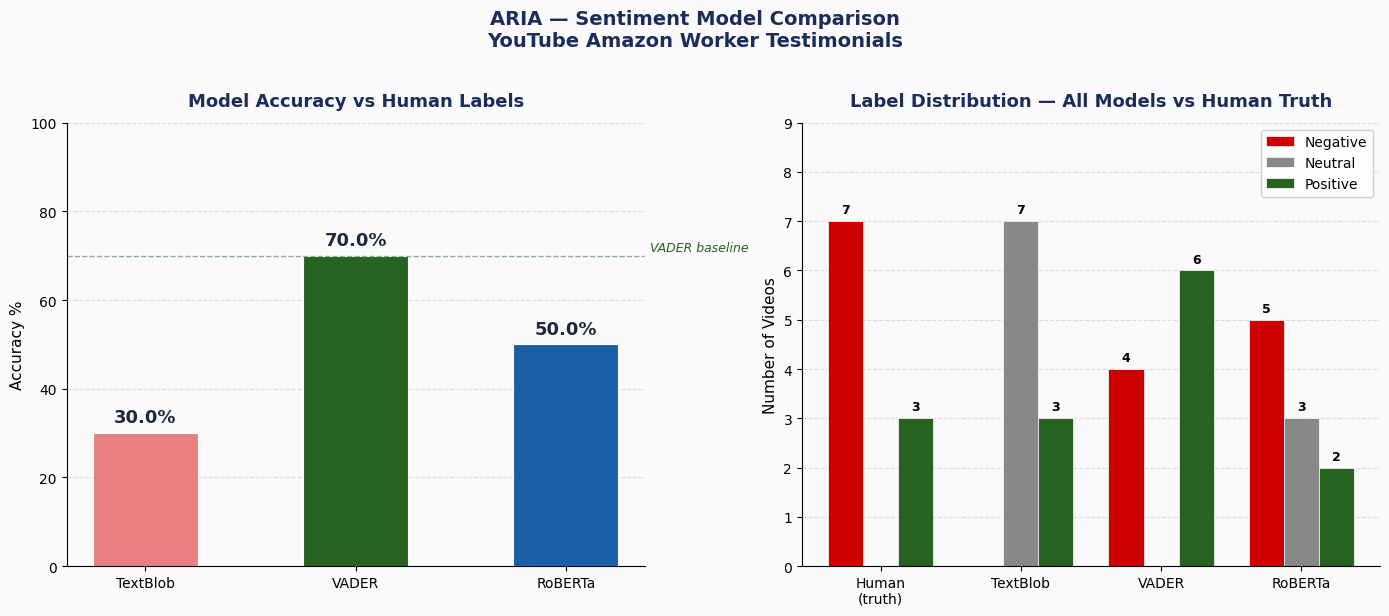

Chart saved: aria_model_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')

# ── CHART 1: Accuracy bar ──────────────────────────────────────
models = ['TextBlob', 'VADER', 'RoBERTa']
accuracies = [30.0, 70.0, 50.0]
colors = ['#E88080', '#276221', '#185FA5']

bars = axes[0].bar(models, accuracies, color=colors,
                   edgecolor='white', linewidth=0.8, width=0.5)

for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.5,
                 f'{acc}%', ha='center', va='bottom',
                 fontsize=13, fontweight='bold', color='#1E293B')

axes[0].set_ylim(0, 100)
axes[0].axhline(y=70, color='#276221', linestyle='--',
                linewidth=1, alpha=0.5)
axes[0].text(2.4, 71, 'VADER baseline', fontsize=9,
             color='#276221', style='italic')
axes[0].set_title('Model Accuracy vs Human Labels',
                  fontsize=13, fontweight='bold',
                  color='#1B2D5B', pad=12)
axes[0].set_ylabel('Accuracy %', fontsize=11)
axes[0].set_facecolor('#FAFAFA')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.4)
axes[0].set_axisbelow(True)

# ── CHART 2: Label distribution ────────────────────────────────
x = range(4)
labels_data = {
    'Negative': [7, 0, 4, 5],
    'Neutral':  [0, 7, 0, 3],
    'Positive': [3, 3, 6, 2],
}
model_names = ['Human\n(truth)', 'TextBlob', 'VADER', 'RoBERTa']
bar_colors = {'Negative':'#CC0000', 'Neutral':'#888888', 'Positive':'#276221'}
width = 0.25
offsets = [-width, 0, width]

for i, (sentiment, counts) in enumerate(labels_data.items()):
    bars2 = axes[1].bar(
        [xi + offsets[i] for xi in x],
        counts,
        width=width,
        label=sentiment,
        color=bar_colors[sentiment],
        edgecolor='white',
        linewidth=0.5
    )
    for bar, val in zip(bars2, counts):
        if val > 0:
            axes[1].text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                str(val),
                ha='center', va='bottom',
                fontsize=9, fontweight='bold'
            )

axes[1].set_xticks(list(x))
axes[1].set_xticklabels(model_names, fontsize=10)
axes[1].set_ylabel('Number of Videos', fontsize=11)
axes[1].set_title('Label Distribution — All Models vs Human Truth',
                  fontsize=13, fontweight='bold',
                  color='#1B2D5B', pad=12)
axes[1].legend(fontsize=10, frameon=True,
               framealpha=0.9, edgecolor='#CCCCCC')
axes[1].set_facecolor('#FAFAFA')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.4)
axes[1].set_axisbelow(True)
axes[1].set_ylim(0, 9)

plt.suptitle('ARIA — Sentiment Model Comparison\nYouTube Amazon Worker Testimonials',
             fontsize=14, fontweight='bold',
             color='#1B2D5B', y=1.02)

plt.tight_layout()
plt.savefig('aria_model_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Chart saved: aria_model_comparison.png")

## Step 7 — Conclusion and Model Decision

In [10]:
print("""
ARIA — SESSION 1 CONCLUSION
============================================================

FINDING: No single model accurately captures sentiment
in long-form spoken Amazon worker testimonials.

RESULTS:
  TextBlob  →  30% accurate  →  Found 0/7 negative videos
  RoBERTa   →  50% accurate  →  Found 5/7 but overcorrected
  VADER     →  70% accurate  →  Best performer on this data

WHY VADER OUTPERFORMED ROBERTA HERE:
  RoBERTa was trained on tweets — short, punchy, emotionally
  direct text. YouTube transcripts are long, spoken, and often
  calm in tone even when describing serious harm. A worker
  describing a permanent back injury in a measured voice does
  not write like an angry tweet.

  VADER's lexicon-based approach catches specific negative
  vocabulary regardless of sentence length or speaking style —
  making it more robust on this content type without fine-tuning.

WHAT THIS MEANS FOR ARIA:
  Model selection must match the data type.
  For YouTube spoken transcripts → VADER is the validated model.
  For a production system → Fine-tuning RoBERTa on warehouse
  worker transcripts would likely close the gap.

FINAL DECISION:
  ARIA Pipeline v1 will use:
  → VADER as the primary sentiment scorer on both datasets
  → RoBERTa results stored as a comparison reference
  → Human-coded labels as the ground truth benchmark

  Manual thematic coding remains more reliable than any
  automated model on this dataset — confirming the value
  of the ARIA thematic tagger built in previous sessions.

SESSION 1 STATUS: COMPLETE
============================================================
""")


ARIA — SESSION 1 CONCLUSION

FINDING: No single model accurately captures sentiment
in long-form spoken Amazon worker testimonials.

RESULTS:
  TextBlob  →  30% accurate  →  Found 0/7 negative videos
  RoBERTa   →  50% accurate  →  Found 5/7 but overcorrected
  VADER     →  70% accurate  →  Best performer on this data

WHY VADER OUTPERFORMED ROBERTA HERE:
  RoBERTa was trained on tweets — short, punchy, emotionally
  direct text. YouTube transcripts are long, spoken, and often
  calm in tone even when describing serious harm. A worker
  describing a permanent back injury in a measured voice does
  not write like an angry tweet.

  VADER's lexicon-based approach catches specific negative
  vocabulary regardless of sentence length or speaking style —
  making it more robust on this content type without fine-tuning.

WHAT THIS MEANS FOR ARIA:
  Model selection must match the data type.
  For YouTube spoken transcripts → VADER is the validated model.
  For a production system → Fine-tunin

In [13]:
from google.colab import files

from google.colab import files

# Save dataset with RoBERTa scores added
df.to_csv('youtube_final_v3.csv', index=False)
files.download('youtube_final_v3.csv')

print("Saved: youtube_final_v3.csv")
print(f"Columns added: roberta_label, roberta_score")
print(f"Total columns: {len(df.columns)}")
print(f"Total rows: {len(df)}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: youtube_final_v3.csv
Columns added: roberta_label, roberta_score
Total columns: 28
Total rows: 10
